In [138]:
%load_ext autoreload
%autoreload 2

# XLA_PYTHON_CLIENT_PREALLOCATE = False
import jax
import jax.numpy as jnp
import equinox as eqx

import numpy as np
import matplotlib.pyplot as plt

from qdots_qll.distributions import Distribution, update_particles_locations, update_weights

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from jax import jit
from jax.scipy.linalg import expm

from qdots_qll.models.single_dot_weak_coupling_GAME import *

from qdots_qll.resamplers import LWResampler

resampler = LWResampler(a=0.95)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [139]:
def det_fim(model, *args, **kwargs):
    return jnp.linalg.det(model.fim(*args, **kwargs))


def choose_given_p(key, discrete_distribution):
    outcomes = jnp.arange(discrete_distribution.shape[0])
    return jax.random.choice(key, outcomes, p=discrete_distribution)



In [150]:
no_particles = 100
no_rv = 4

print(true_parameters)
seed = 1
key = jax.random.PRNGKey(seed)
key, subkey = jax.random.split(key)

model = SingleDotWeakCouplingGAME()

no_initial_states = 4
no_measurement_basis = 3
dist_initial_state = jnp.ones(no_initial_states) / no_initial_states
dist_measurement_basis = jnp.ones(no_measurement_basis) / no_measurement_basis

initial_covariance = jnp.diagflat(jnp.ones(4) * 0.05) ** 2
particles_locations = jax.random.multivariate_normal(subkey,
                                                     mean=true_parameters,
                                                     cov=initial_covariance,
                                                     shape=(no_particles,))

weights = jnp.ones(no_particles) / no_particles

distribution = Distribution(particles_locations, weights)
# 
# key, subkey = jax.random.split(key)
# particles = jax.random.normal(subkey, (no_particles, no_rv))
# 
# key, subkey = jax.random.split(key)
# new_particles = jax.random.normal(subkey, (no_particles, no_rv))

[ 0.3142169   0.35833007  0.05385149 -0.33369482]


In [155]:
jnp.log10(jnp.abs(true_parameters))

Array([-0.5027704 , -0.4457167 , -1.2688023 , -0.47665054], dtype=float32)

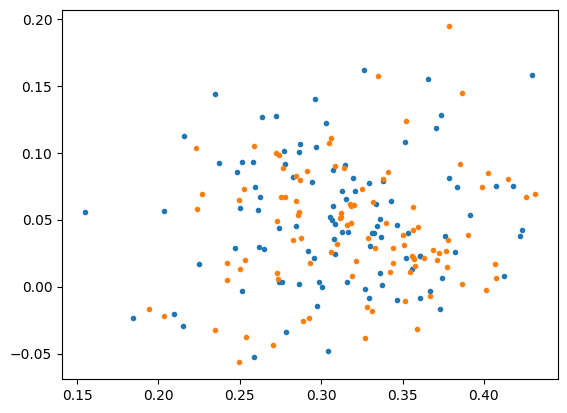

In [153]:
i, j = 0, 2

plt.plot(distribution.particles_locations[:, i], distribution.particles_locations[:, j], '.')

key, new_weights, new_particles_locations = resampler.resample(key, distribution.particles_locations,
                                                               distribution.weights).values()

new_distribution = update_particles_locations(distribution, new_particles_locations)
new_distribution = update_weights(new_distribution, new_weights)

plt.plot(new_distribution.particles_locations[:, i], new_distribution.particles_locations[:, j], '.')



In [123]:
distribution.ev()

Array([ 0.3001563 ,  0.3381468 ,  0.03921792, -0.3330848 ], dtype=float32)

In [124]:
distribution.check_resampling()

Array(False, dtype=bool)

In [20]:
model.fim?

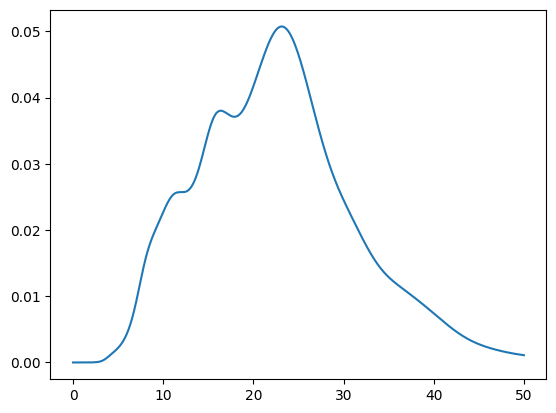

In [24]:
times = jnp.linspace(0, 50, 1000)

det_fim_times = jax.vmap(lambda t: det_fim(model, particle=true_parameters, t=t, prob_initial_state=dist_initial_state,
                                           prob_measurement_basis=dist_measurement_basis))(
    times)

plt.plot(times, det_fim_times)

In [114]:
key, subkey = jax.random.split(key)
choose_given_p(subkey, dist_initial_state)

Array(0, dtype=int32)

In [133]:
key, new_weights, new_particles_locations = resampler.resample(key, distribution.particles_locations,
                                                               distribution.weights).values()

distribution = update_particles_locations(distribution, new_particles_locations)
distribution = update_weights(distribution, new_weights)

In [134]:
distribution.ev()

Array([ 0.31380197,  0.3722461 ,  0.04306908, -0.33396986], dtype=float32)

In [156]:
jax.random.truncated_normal?

In [157]:
from tensorflow_probability.substrates import jax as tfp

In [159]:
tfp.distributions.TruncatedNormal?

In [192]:
boundaries = jnp.array([
    [0.01, 0.9],
    [0.01, 0.9],
    [0.001, 0.22],
    [-0.9, -0.01],
])

In [193]:
boundaries

Array([[ 0.01 ,  0.9  ],
       [ 0.01 ,  0.9  ],
       [ 0.001,  0.22 ],
       [-0.9  , -0.01 ]], dtype=float32)

In [194]:
mus = boundaries.mean(axis=1)
sigmas = jnp.abs((boundaries[:, 0] - boundaries[:, 1]) / (2 * 4))

In [216]:
key, subkey = jax.random.split(key)
tfp.distributions.TruncatedNormal(loc=mus, scale=sigmas, low=boundaries[:, 0], high=boundaries[:, 1]).sample(
    seed=subkey, sample_shape=5)

Array([[ 0.2940829 ,  0.4065484 ,  0.14498547, -0.4072619 ],
       [ 0.6114788 ,  0.48330665,  0.09216013, -0.3866218 ],
       [ 0.380369  ,  0.3534275 ,  0.06519368, -0.55965596],
       [ 0.43823108,  0.3251667 ,  0.1710286 , -0.5130602 ],
       [ 0.3693275 ,  0.50339204,  0.11098459, -0.48272222]],      dtype=float32)

In [196]:
boundaries[:, 1]

Array([ 0.9 ,  0.9 ,  0.22, -0.01], dtype=float32)

In [197]:
boundaries[:, 0]

Array([ 0.01 ,  0.01 ,  0.001, -0.9  ], dtype=float32)

In [211]:
jnp.diag(sigmas)

Array([[0.11125 , 0.      , 0.      , 0.      ],
       [0.      , 0.11125 , 0.      , 0.      ],
       [0.      , 0.      , 0.027375, 0.      ],
       [0.      , 0.      , 0.      , 0.11125 ]], dtype=float32)

In [219]:
jnp.linalg.cholesky(distribution.cov()).T

Array([[0.0542278 , 0.00470918, 0.00250394, 0.00012613],
       [0.        , 0.04293731, 0.00298278, 0.0066253 ],
       [0.        , 0.        , 0.04706099, 0.00513704],
       [0.        , 0.        , 0.        , 0.04461069]], dtype=float32)

In [220]:
boundaries

Array([[ 0.01 ,  0.9  ],
       [ 0.01 ,  0.9  ],
       [ 0.001,  0.22 ],
       [-0.9  , -0.01 ]], dtype=float32)

In [222]:
good_particle = true_parameters
bad_particle = jnp.array([0.1, 0.2, -0.1, -0.7])

test_pars = jnp.array([good_particle, bad_particle])

In [227]:
boundaries[:, 0] < test_pars

Array([[ True,  True,  True,  True],
       [ True,  True, False,  True]], dtype=bool)

In [235]:
(boundaries[:, 1] > test_pars[0]).prod()

Array(1, dtype=int32)

In [247]:
def is_valid_particle(particle, boundaries):
    return (jnp.logical_and(boundaries[:, 0] < particle, (boundaries[:, 1] > particle))).prod()

In [242]:
jnp.array([True, True]).sum()

Array(2, dtype=int32)

In [248]:
is_valid_particle(good_particle, boundaries)

Array(1, dtype=int32)

In [253]:
is_valid_particle(bad_particle, boundaries) 

Array(0, dtype=int32)

In [255]:
jax.vmap(lambda par: jax.lax.cond(is_valid_particle(par, boundaries), lambda par: par, lambda _: , par))(test_pars)

Array([ True, False], dtype=bool)